In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('c:/data/ozone/ozone2.csv')
df.head()

,Month,Day,Solar.R,Wind,Temp,Ozone,Result
0,5,1,190.000000,7.4,67,41,0
1,5,2,118.000000,8.0,72,36,0
2,5,3,149.000000,12.6,74,12,0
3,5,4,313.000000,11.5,62,18,0
4,5,5,185.931507,14.3,56,42,1


In [3]:
df.columns

Index(['Month', 'Day', 'Solar.R', 'Wind', 'Temp', 'Ozone', 'Result'], dtype='object')

In [4]:
X = df[['Solar.R', 'Wind', 'Temp']].values.astype(np.float32)
y = df[['Ozone']].values.astype(np.float32)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 10)

In [6]:
sc_X = StandardScaler()
X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

In [7]:
sc_y = StandardScaler()
y_train_scaled = sc_y.fit_transform(y_train)
y_test_scaled = sc_y.transform(y_test)

In [8]:
inputs = torch.from_numpy(X_train_scaled)
targets = torch.from_numpy(y_train_scaled)

In [9]:
input_dim = X_train.shape[1]
model = nn.Sequential(
    nn.Linear(input_dim, 32),  #input_dim 변수개수
    nn.ReLU(),
    nn.Linear(32,16),
    nn.ReLU(),
    nn.Linear(16,1)
)
print(model)

Sequential(
  (0): Linear(in_features=3, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)


In [10]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_list=[]
iteration_number = 2000

for iteration in range(iteration_number):
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.item())

    if iteration % 100 == 0:
        print(f'epoch {iteration}, loss {loss.item():.4f}')

epoch 0, loss 0.9776
epoch 100, loss 0.3665
epoch 200, loss 0.3132
epoch 300, loss 0.2851
epoch 400, loss 0.2640
epoch 500, loss 0.2469
epoch 600, loss 0.2310
epoch 700, loss 0.2093
epoch 800, loss 0.1876
epoch 900, loss 0.1683
epoch 1000, loss 0.1526
epoch 1100, loss 0.1318
epoch 1200, loss 0.1110
epoch 1300, loss 0.0957
epoch 1400, loss 0.0827
epoch 1500, loss 0.0729
epoch 1600, loss 0.0656
epoch 1700, loss 0.0600
epoch 1800, loss 0.0557
epoch 1900, loss 0.0522


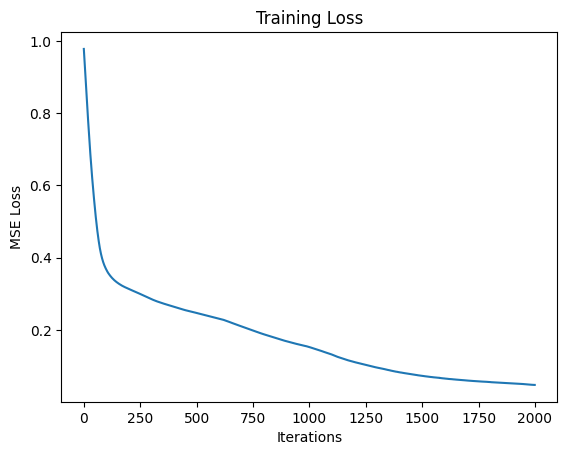

In [11]:
plt.plot(loss_list)
plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.show()

In [12]:
X_test_tensor = torch.from_numpy(X_test_scaled)
y_pred_scaled = model(X_test_tensor).detach().numpy()
y_pred = sc_y.inverse_transform(y_pred_scaled)

In [13]:
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
print(f'MSE: {mse:.4f}, RMSE: {rmse:.4f}')

MSE: 420.1669, RMSE: 20.4980


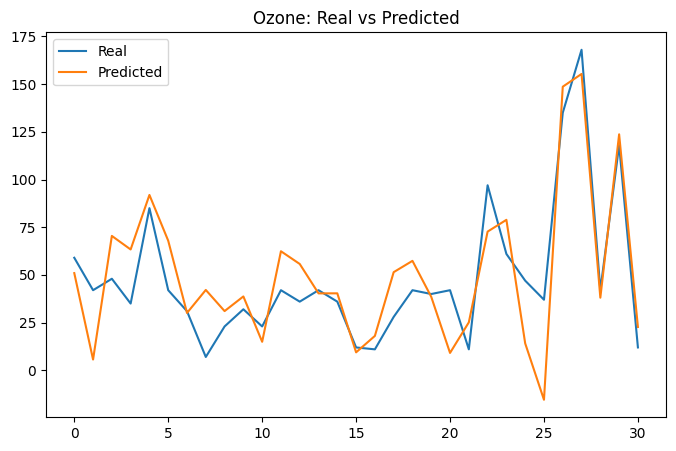

In [14]:
plt.figure(figsize=(8,5))
plt.plot(y_test, label='Real')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title('Ozone: Real vs Predicted')
plt.show()